In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from arch import arch_model

import sys
import os

sys.path.append(os.path.abspath("../src"))

In [13]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import scipy
import statsmodels
import arch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("arch:", arch.__version__)

numpy: 1.26.4
pandas: 2.2.3
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.17.1
statsmodels: 0.14.6
arch: 8.0.0


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

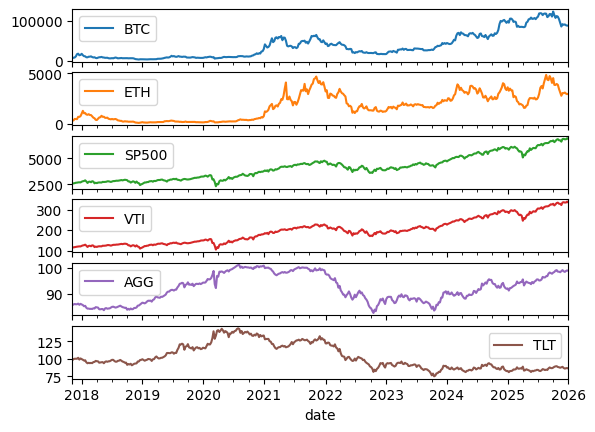

In [2]:
# initialize dataframe with eth has it has the shortest date range
df = pd.read_csv("../data/merged_data_v2.csv", index_col='date')
df.dropna(inplace=True)
df.index= pd.to_datetime(df.index, format = '%Y-%m-%d')
weekly_df = df[["btc_adj_close", "eth_adj_close", "sp500_adj_close", "vti_adj_close", "agg_adj_close", "tlt_adj_close"]].resample("W-FRI").last().dropna()
weekly_df.columns = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
weekly_df.plot(subplots=True)

In [3]:
price_assets = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"] # treasury yield is in rates, will be treated differently
weekly_logret = 100*np.log(weekly_df[price_assets] / weekly_df[price_assets].shift(1)).dropna()
weekly_logret.head()

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-11-17,15.257283,10.503171,-0.133689,0.075442,0.293155,1.828457
2017-11-24,6.827321,35.680639,0.909815,1.102159,0.200999,0.323876
2017-12-01,28.501417,-1.778366,1.517771,1.450900,-0.126307,0.006617
2017-12-08,41.188305,-2.278298,0.350606,0.300862,0.027492,0.110589
2017-12-15,6.639677,40.605187,0.912664,0.780926,0.256062,1.301817


In [4]:
print(f"Weekly obs : {len(weekly_logret)}")
print(f"Date range : {weekly_logret.index[0].date()} → {weekly_logret.index[-1].date()}")
print(f"\nMissing values:\n{weekly_logret.isnull().sum()}")
print(f"\nDescriptive stats:\n{weekly_logret.describe().round(4)}")
# as expected, volatility of crypto>stocks>bonds

Weekly obs : 425
Date range : 2017-11-17 → 2026-01-02

Missing values:
BTC      0
ETH      0
SP500    0
VTI      0
AGG      0
TLT      0
dtype: int64

Descriptive stats:
            BTC       ETH     SP500       VTI       AGG       TLT
count  425.0000  425.0000  425.0000  425.0000  425.0000  425.0000
mean     0.6075    0.5398    0.2294    0.2492    0.0335   -0.0301
std      9.3644   12.0246    2.5695    2.6347    0.7719    2.0308
min    -49.4484  -60.3355  -16.2279  -16.5557   -5.2249   -8.0053
25%     -3.5334   -5.6784   -1.0172   -1.0605   -0.3461   -1.1682
50%      0.3681    0.2524    0.4872    0.5327    0.0567    0.0789
75%      5.0951    7.0441    1.6065    1.6849    0.4084    1.1863
max     41.1883   50.6363   11.4237   12.1791    4.9123    7.2668


## GARCH Volatility Modelling

In [5]:
from models.garch_functions import fit_all_garch, plot_garch_diagnostics, diagnostics_summary_table

In [6]:
garch_results = fit_all_garch(weekly_logret, model_type="auto")
plot_garch_diagnostics(garch_results)
diag_table = diagnostics_summary_table(garch_results)
cond_vol_df = pd.DataFrame({
    asset: garch_results[asset]["cond_vol"]
    for asset in garch_results
}).dropna()


GARCH fit: BTC

  --------------------------------------------------
  AR(1) mean detected (LB p=0.0843) -- using AR(1) mean equation

  Model competition [primary=skewt, mean=AR]:
  Model            Dist            AIC        BIC     Status
  --------------------------------------------------------
  GARCH            skewt       3019.33    3047.68         ok
  GJR              skewt       3013.32    3045.72         ok
  EGARCH           skewt            --         --   no convergence -> retrying with GED
  EGARCH           ged         3004.91    3033.26 GED fallback

  -> BIC selects: EGARCH-GED  (BIC=3033.26)
  EGARCH |beta|=0.9960  ->  stationary  |  near-IGARCH -- shocks near-permanent (half-life ~174 weeks)

  Post-fit [EGARCH-GED]:
  Ljung-Box resid   p@10=0.8288  p@20=0.6025
  Ljung-Box resid^2 p@10=0.7139  p@20=0.7769
  ARCH LM [std residuals -- post EGARCH]  LM=8.8767  p=0.7134  F=0.7322  p=0.7200  ->  no ARCH effects

  Normality / tail check [BTC]
  Obs                     

  EGARCH           skewt        833.02     861.38         ok

  -> BIC selects: GARCH-SKEWT  (BIC=859.11)
  GARCH alpha+beta=0.9768  ->  stationary  |  highly persistent (half-life ~30 weeks)

  Post-fit [GARCH-SKEWT]:
  Ljung-Box resid   p@10=0.8813  p@20=0.7958
  Ljung-Box resid^2 p@10=0.6879  p@20=0.8854
  ARCH LM [std residuals -- post GARCH]  LM=8.0786  p=0.7790  F=0.6650  p=0.7851  ->  no ARCH effects

  Normality / tail check [AGG]
  Obs                             : 425
  Skewness                        : -0.4945  (ok)
  Excess kurtosis                 : 2.1381  (fat tails remain)
  Jarque-Bera                     : stat=98.2779  p=0.0000  [informational only (skewt is non-normal by design)]
  KS vs normal (ref only)         : stat=0.0463  p=0.3128  [not meaningful for skewt]
  KS vs t: nu=None -- cannot run (df <= 2)
  [i] Excess kurtosis=2.14 -- mild fat tails remain after skewt -- GED refit will be attempted

  -> Refitting GARCH with GED (distribution test only) ...

  Post


GARCH fit: BTC

  --------------------------------------------------
  AR(1) mean detected (LB p=0.0843) -- using AR(1) mean equation

  Model competition [primary=skewt, mean=AR]:
  Model            Dist            AIC        BIC     Status
  --------------------------------------------------------
  GARCH            skewt       3019.33    3047.68         ok
  GJR              skewt       3013.32    3045.72         ok
  EGARCH           skewt            --         --   no convergence -> retrying with GED
  EGARCH           ged         3004.91    3033.26 GED fallback

  -> BIC selects: EGARCH-GED  (BIC=3033.26)
  EGARCH |beta|=0.9960  ->  stationary  |  near-IGARCH -- shocks near-permanent (half-life ~174 weeks)

  Post-fit [EGARCH-GED]:
  Ljung-Box resid   p@10=0.8288  p@20=0.6025
  Ljung-Box resid^2 p@10=0.7139  p@20=0.7769
  ARCH LM [std residuals -- post EGARCH]  LM=8.8767  p=0.7134  F=0.7322  p=0.7200  ->  no ARCH effects

  Normality / tail check [BTC]
  Obs                     

  GARCH            skewt        834.80     859.11         ok
  GJR              skewt        836.79     865.15         ok
  EGARCH           skewt        833.02     861.38         ok

  -> BIC selects: GARCH-SKEWT  (BIC=859.11)
  GARCH alpha+beta=0.9768  ->  stationary  |  highly persistent (half-life ~30 weeks)

  Post-fit [GARCH-SKEWT]:
  Ljung-Box resid   p@10=0.8813  p@20=0.7958
  Ljung-Box resid^2 p@10=0.6879  p@20=0.8854
  ARCH LM [std residuals -- post GARCH]  LM=8.0786  p=0.7790  F=0.6650  p=0.7851  ->  no ARCH effects

  Normality / tail check [AGG]
  Obs                             : 425
  Skewness                        : -0.4945  (ok)
  Excess kurtosis                 : 2.1381  (fat tails remain)
  Jarque-Bera                     : stat=98.2779  p=0.0000  [informational only (skewt is non-normal by design)]
  KS vs normal (ref only)         : stat=0.0463  p=0.3128  [not meaningful for skewt]
  KS vs t: nu=None -- cannot run (df <= 2)
  [i] Excess kurtosis=2.14 -- mild fat t

FileNotFoundError: [Errno 2] No such file or directory: 'output/garch_diagnostics.png'

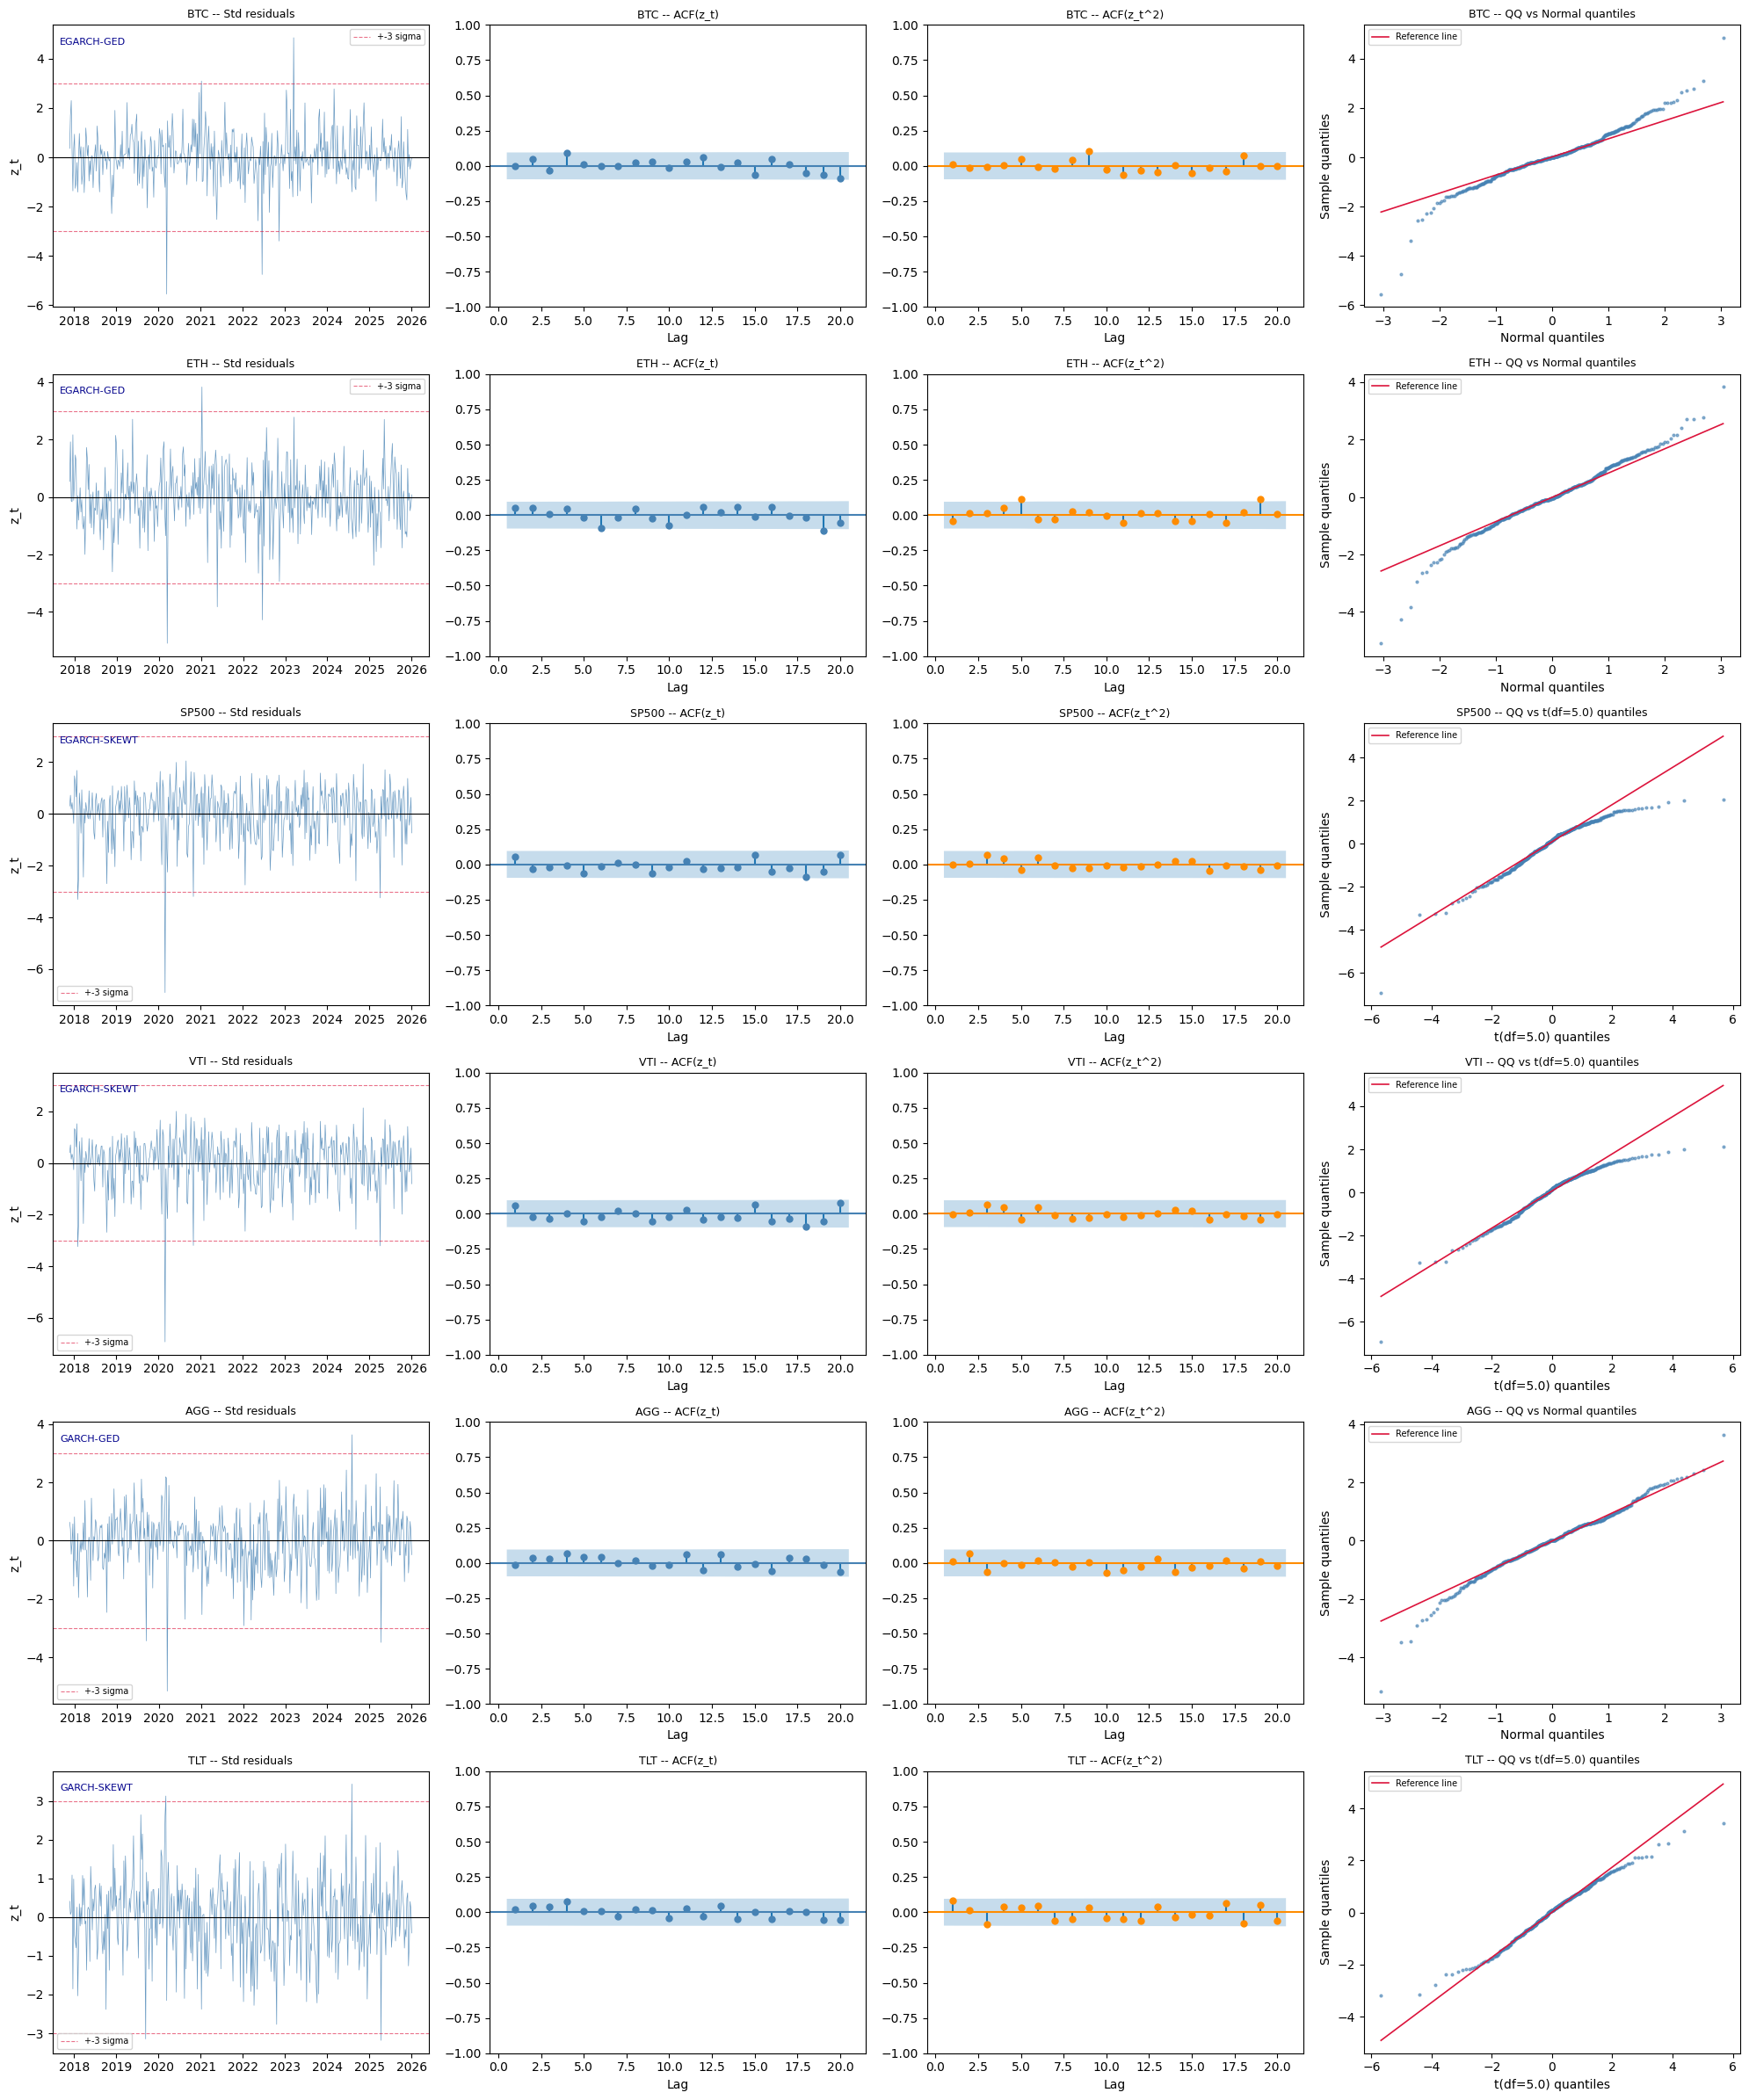

In [12]:
garch_results = fit_all_garch(weekly_logret, model_type="auto")
plot_garch_diagnostics(garch_results)
diag_table = diagnostics_summary_table(garch_results)
cond_vol_df = pd.DataFrame({
    asset: garch_results[asset]["cond_vol"]
    for asset in garch_results
}).dropna()

In [7]:
# run to this cell
diag_table

,Model,alpha,gamma,beta,Persistence,Metric,Stationary,Interpretation,Skewness,Excess Kurt,JB p-val,ARCH post p,AIC,BIC
Asset,,,,,,,,,,,,,,
BTC,EGARCH-GED,0.0190,0.0528,0.9960,0.9960,|beta|,OK,near-IGARCH -- shocks near-permanent (half-lif...,-0.2650,4.4044,0.0000,0.7134,3004.91,3033.26
ETH,EGARCH-GED,-0.0365,0.0308,0.9927,0.9927,|beta|,OK,near-IGARCH -- shocks near-permanent (half-lif...,-0.4005,2.2689,0.0000,0.6040,3258.47,3282.79
SP500,EGARCH-SKEWT,0.2013,-0.2571,0.9075,0.9075,|beta|,OK,highly persistent (half-life ~7 weeks),-1.2768,4.7203,0.0000,0.9459,1808.30,1840.70
VTI,EGARCH-SKEWT,0.2265,-0.2451,0.9119,0.9119,|beta|,OK,highly persistent (half-life ~8 weeks),-1.2655,4.7422,0.0000,0.9517,1831.78,1864.17
AGG,GARCH-GED,0.2660,--,0.7070,0.9768,alpha+beta,OK,highly persistent (half-life ~30 weeks),-0.4712,2.0392,0.0000,0.8295,839.51,859.77
TLT,GARCH-SKEWT,0.1071,--,0.8416,0.9488,alpha+beta,OK,highly persistent (half-life ~13 weeks),-0.1401,0.4929,0.0585,0.3219,1769.78,1798.13


In [14]:
diag_table

,Model,alpha,gamma,beta,Persistence,Metric,Stationary,Interpretation,Skewness,Excess Kurt,JB p-val,ARCH post p,AIC,BIC
Asset,,,,,,,,,,,,,,
BTC,EGARCH-GED,-0.0502,0.0483,0.9966,0.9966,|beta|,OK,near-IGARCH -- shocks near-permanent (half-lif...,0.1068,3.0259,0.0000,0.4183,2996.36,3024.71
ETH,EGARCH-GED,-0.0603,0.0345,0.9915,0.9915,|beta|,OK,near-IGARCH -- shocks near-permanent (half-lif...,-0.3219,1.8131,0.0000,0.5914,3253.62,3277.93
SP500,EGARCH-SKEWT,0.2013,-0.2571,0.9075,0.9075,|beta|,OK,highly persistent (half-life ~7 weeks),-1.2768,4.7203,0.0000,0.9459,1808.30,1840.70
VTI,EGARCH-SKEWT,0.2265,-0.2451,0.9119,0.9119,|beta|,OK,highly persistent (half-life ~8 weeks),-1.2655,4.7424,0.0000,0.9517,1831.78,1864.17
AGG,GARCH-GED,0.2660,--,0.7070,0.9768,alpha+beta,OK,highly persistent (half-life ~30 weeks),-0.4712,2.0392,0.0000,0.8295,839.51,859.77
TLT,GARCH-SKEWT,0.1071,--,0.8416,0.9488,alpha+beta,OK,highly persistent (half-life ~13 weeks),-0.1401,0.4928,0.0585,0.3220,1769.78,1798.13


In [8]:
import pickle

with open("../output/models/garch_results.pkl", "wb") as f:
    pickle.dump(cond_vol_df, f)

## Cleaning Bubble Indicators

In [11]:
%run ../src/tests/GSADF_and_BSADF_tests.py

FileNotFoundError: [Errno 2] No such file or directory: '../data/merged_data.csv'

In [17]:
with open("gsadf_results.pkl", "rb") as f:
    results = pickle.load(f)

In [27]:
bubble_rows = []

for asset, res in results.items():
    for start, end in res["bubbles"]:
        bubble_rows.append({
            "asset": asset,
            "start_date": pd.to_datetime(start),
            "end_date": pd.to_datetime(end)
        })

bubble_df = pd.DataFrame(bubble_rows)
dates = cond_vol_df.index
bubble_dummy = pd.DataFrame(0, index=dates, columns=["BTC", "ETH"])

for _, row in bubble_df.iterrows():
    mask = (bubble_dummy.index >= row["start_date"]) & (bubble_dummy.index <= row["end_date"])
    bubble_dummy.loc[mask, row["asset"]] = 1

bubble_dummy

,BTC,ETH
date,,
2017-11-24,1,0
2017-12-01,1,0
2017-12-08,1,0
2017-12-15,1,0
2017-12-22,1,0
...,...,...
2025-12-05,0,0
2025-12-12,0,0
2025-12-19,0,0


In [38]:
with open("../output/models/bubble_dummy.pkl", "wb") as f:
    pickle.dump(bubble_dummy, f)

In [32]:
def plot_conditional_volatility(garch_results: dict,
                                 bubble_indicators: pd.DataFrame,
                                 save_path: str = "output/conditional_volatility.png"):
    """Conditional volatility for all assets with bubble episode shading.
    
    Args:
        garch_results: Dict with asset keys containing 'cond_vol', 'model_type', 'dist'
        bubble_indicators: DataFrame with dates as index, assets as columns, 
                          binary values (1=bubble, 0=no bubble)
    """
    assets = list(garch_results.keys())
    fig, axes = plt.subplots(len(assets), 1,
                             figsize=(16, 3 * len(assets)), sharex=True)
    if len(assets) == 1:
        axes = [axes]
    
    for ax, asset in zip(axes, assets):
        cv   = garch_results[asset]["cond_vol"]
        dist = garch_results[asset].get("dist", "skewt")
        mod  = garch_results[asset]["model_type"]
        
        ax.fill_between(cv.index, cv.values, alpha=0.6,
                        color="steelblue", label=f"{asset} sigma_t")
        ax.set_ylabel("Cond. vol (%)")
        ax.set_title(f"{asset} -- {mod}(1,1)-{dist.upper()}")
        
        # Extract bubble episodes from binary indicators
        if asset in bubble_indicators.columns:
            bubble_series = bubble_indicators[asset]
            
            # Find continuous bubble episodes
            in_bubble = False
            bubble_start = None
            label_added = False
            
            for date, value in bubble_series.items():
                if value == 1 and not in_bubble:
                    # Bubble episode starts
                    bubble_start = date
                    in_bubble = True
                elif value == 0 and in_bubble:
                    # Bubble episode ends
                    ax.axvspan(bubble_start, date, alpha=0.18, color="crimson",
                               label="bubble" if not label_added else "")
                    label_added = True
                    in_bubble = False
            
            # Handle case where bubble extends to end of data
            if in_bubble and bubble_start is not None:
                ax.axvspan(bubble_start, bubble_series.index[-1], 
                           alpha=0.18, color="crimson",
                           label="bubble" if not label_added else "")
        
        ax.legend(fontsize=8, loc="upper right")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Saved: {save_path}")

In [33]:
plot_conditional_volatility(garch_results, bubble_dummy)

Saved: output/conditional_volatility.png
